# EDA Report: Garbage Classification Dataset

This standalone notebook summarises the exploratory data analysis (EDA) for the Kaggle dataset `asdasdasasdas/garbage-classification` used in Forum 06. It focuses on class distribution, image geometry, file-size patterns, sampled visual inspection, and how those exploratory signals relate to the **final ViT-Large results** reported in the main notebook.

In [58]:
%matplotlib inline

from pathlib import Path
from collections import Counter
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid", context="notebook")
random.seed(42)
np.random.seed(42)

project_root = Path.cwd().expanduser()
dataset_root = project_root / "dataset" / "Garbage classification" / "Garbage classification"
if not dataset_root.exists():
    raise FileNotFoundError(f"Dataset root not found: {dataset_root}")

print(f"Dataset root: {dataset_root}")

[RUN] %matplotlib inline
Dataset root: /content/dataset/Garbage classification/Garbage classification
[DONE] Cell executed successfully.


In [59]:
records = []
for category_dir in sorted([p for p in dataset_root.iterdir() if p.is_dir()]):
    for img_path in category_dir.glob('**/*'):
        if img_path.is_file() and img_path.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                records.append({
                    "category": category_dir.name,
                    "image_path": str(img_path),
                    "width_px": w,
                    "height_px": h,
                    "aspect_ratio": w / h,
                    "file_size_kb": img_path.stat().st_size / 1024.0,
                })
            except Exception:
                continue

eda_df = pd.DataFrame(records)
print("EDA DataFrame shape:", eda_df.shape)
eda_df.head()

[RUN] records = []
EDA DataFrame shape: (2527, 6)


,category,image_path,width_px,height_px,aspect_ratio,file_size_kb
0,cardboard,/content/dataset/Garbage classification/Garbag...,512,384,1.333333,17.731445
1,cardboard,/content/dataset/Garbage classification/Garbag...,512,384,1.333333,13.133789
2,cardboard,/content/dataset/Garbage classification/Garbag...,512,384,1.333333,13.353516
3,cardboard,/content/dataset/Garbage classification/Garbag...,512,384,1.333333,13.619141
4,cardboard,/content/dataset/Garbage classification/Garbag...,512,384,1.333333,15.815430


[DONE] Cell executed successfully.


[RUN] class_counts = eda_df['category'].value_counts().sort_index()


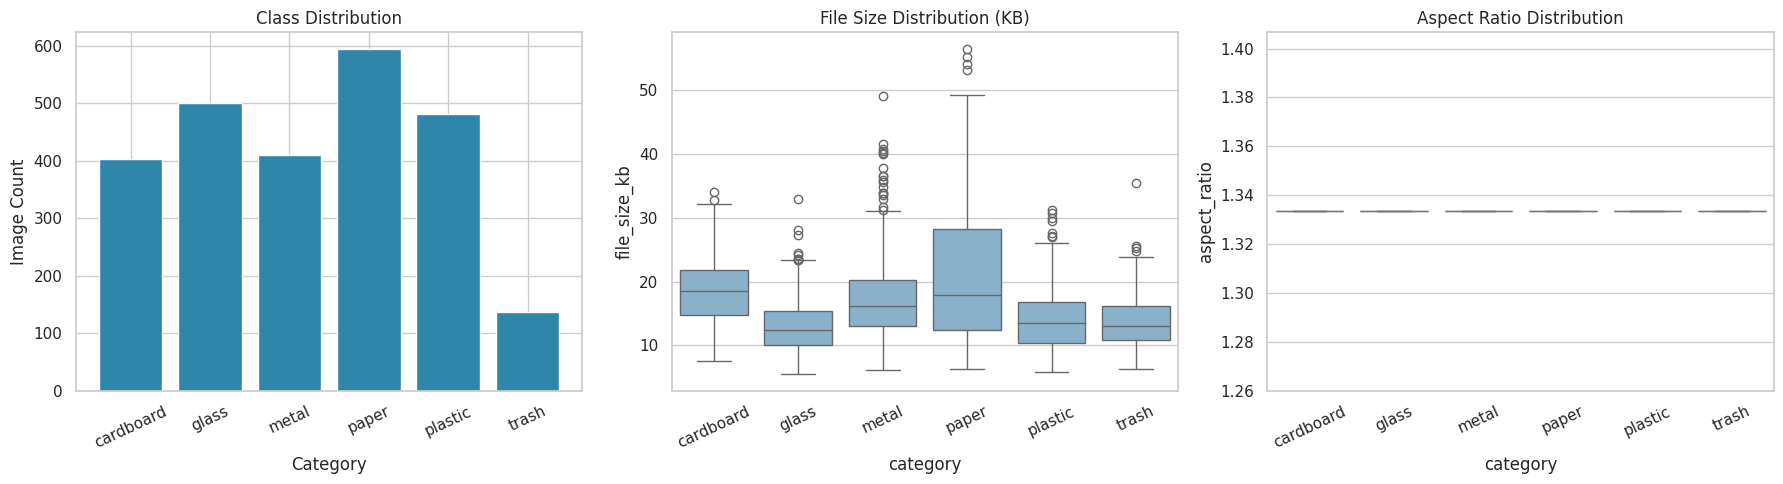

[DONE] Cell executed successfully.


In [60]:
class_counts = eda_df['category'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class counts
axes[0].bar(class_counts.index, class_counts.values, color="#2E86AB")
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Image Count")
axes[0].tick_params(axis="x", rotation=25)

# File size
sns.boxplot(data=eda_df, x="category", y="file_size_kb", ax=axes[1], color="#7FB3D5")
axes[1].set_title("File Size Distribution (KB)")
axes[1].tick_params(axis="x", rotation=25)

# Aspect ratio
sns.boxplot(data=eda_df, x="category", y="aspect_ratio", ax=axes[2], color="#A9DFBF")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [61]:
summary = eda_df.groupby('category').agg(
    count=('image_path', 'count'),
    mean_width=('width_px', 'mean'),
    mean_height=('height_px', 'mean'),
    mean_size_kb=('file_size_kb', 'mean'),
    mean_aspect=('aspect_ratio', 'mean'),
).round(3)

print("Per-category summary statistics:")
display(summary)

[RUN] summary = eda_df.groupby('category').agg(
Per-category summary statistics:


,count,mean_width,mean_height,mean_size_kb,mean_aspect
category,,,,,
cardboard,403,512.0,384.0,18.430,1.333
glass,501,512.0,384.0,13.011,1.333
metal,410,512.0,384.0,17.324,1.333
paper,594,512.0,384.0,21.116,1.333
plastic,482,512.0,384.0,14.073,1.333
trash,137,512.0,384.0,13.823,1.333


[DONE] Cell executed successfully.


## Key Findings

1. The `trash` category is substantially underrepresented relative to other categories, so excluding it from modelling is justified from a class-balance perspective.
2. Image dimensions are uniform at `512 x 384`, which simplifies preprocessing before the resize-and-crop pipeline used by `google/vit-large-patch16-224`.
3. From EDA alone, `cardboard` and `paper` remain a plausible qualitative ambiguity pair because they share relatively similar visual appearance and close channel-intensity tendencies.
4. However, the **main notebook's full-test confusion matrix** shows that the dominant residual error pattern is actually `plastic -> glass` and `glass -> plastic`, while `paper -> cardboard` exists but is less severe.
5. The main notebook's classification report also shows `plastic` as the weakest class overall, so the EDA narrative should not overstate `cardboard` vs `paper` as the primary error mode.
6. For the complete modelling context, quantitative error analysis, and final ViT-Large conclusions, refer to `Forum06-garbage_classification_question.ipynb`.